# Toxic Comment Detection Main Training Pipeline
**Model:** SGD Classifier  
**Features:** Word TF-IDF + Char TF-IDF + Engineering Features (Oangsa + Ploy)

## 1. Imports

In [1]:
!pip install scipy

In [2]:
!pip install scikit-learn

In [3]:
!pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 13.8 MB/s eta 0:00:00


In [4]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import contractions

from scipy.sparse import hstack, csr_matrix

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, ConfusionMatrixDisplay
)

print('All imports OK')

All imports OK


## 2. Load & Clean Data

In [5]:
df = pd.read_csv('train.csv')

# keep only toxic label
df = df.drop(columns=['severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate'])

def clean_text(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = contractions.fix(text)
    text = re.sub(r'http\S+|www\S+', ' URL ', text)
    text = re.sub(r'[^a-z]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['raw_text']   = df['comment_text'].fillna('').astype(str)
df['clean_text'] = df['raw_text'].apply(clean_text)
df = df[df['clean_text'] != ''].copy()
df = df.drop_duplicates(subset=['clean_text'])
df = df.reset_index(drop=True)

print(f'Dataset shape: {df.shape}')
print(df['toxic'].value_counts())

Dataset shape: (158194, 5)
toxic
0    143038
1     15156
Name: count, dtype: int64


## 3. Feature Engineering

In [6]:
# ── Dictionaries & Patterns ──────────────────────────────────────────────────

PROFANITY_TERMS = [
    'fuck', 'fucking', 'shit', 'bitch', 'bastard', 'asshole', 'idiot', 'moron',
    'dumb', 'stupid', 'suck', 'crap', 'damn', 'jerk', 'loser', 'trash'
]
IDENTITY_TERMS = [
    'black', 'white', 'gay', 'lesbian', 'transgender', 'trans', 'muslim',
    'jewish', 'christian', 'hispanic', 'asian', 'woman', 'women', 'man', 'men'
]
SECOND_PERSON_TERMS = ['you', 'your', 'yours', 'yourself', 'u']
NEGATION_TERMS     = ['not', 'never', 'no', 'none', 'cannot', 'cant', 'do not']
NON_TOXIC_NEGATION_PATTERNS = [
    r'\bnot\s+(?:stupid|dumb|idiot|moron|trash|wrong|bad|terrible|awful|useless)\b',
    r'\bnot\s+(?:an|a)\s+(?:idiot|moron|loser|bastard|fool)\b',
    r'\bdo\s+not\s+(?:like|love|agree|hate|dislike|attack|insult|blame)\b',
    r'\bcannot\s+(?:hate|blame)\b',
    r'\bnot\s+trying\s+to\s+(?:attack|insult|offend)\b',
]
COMMON_SHORT_TOKENS = {
    'i','me','my','you','your','yours','yourself','it','this','that',
    'a','an','the','is','am','are','was','were','be','to','of','and'
}

def make_term_pattern(terms):
    escaped = sorted((re.escape(t) for t in terms), key=len, reverse=True)
    return re.compile(r'\b(?:' + '|'.join(escaped) + r')\b')

PROFANITY_PATTERN          = make_term_pattern(PROFANITY_TERMS)
IDENTITY_PATTERN           = make_term_pattern(IDENTITY_TERMS)
SECOND_PERSON_PATTERN      = make_term_pattern(SECOND_PERSON_TERMS)
NEGATION_PATTERN           = make_term_pattern(NEGATION_TERMS)
NON_TOXIC_NEGATION_PATTERN = re.compile('|'.join(NON_TOXIC_NEGATION_PATTERNS))

def count_pattern(text, pattern):
    return len(pattern.findall(str(text).lower()))

def repeated_characters_score(text):
    return len(re.findall(r'(.)\1{2,}', str(text).lower()))

def repeated_punctuation_count(text):
    return len(re.findall(r'([!?.,])\1+', str(text)))

def uppercase_ratio(text):
    letters = re.findall(r'[A-Za-z]', str(text))
    if not letters:
        return 0.0
    return sum(1 for c in letters if c.isupper()) / len(letters)

def short_unclear_without_toxic_signal(clean_text, profanity_count):
    tokens = str(clean_text).split()
    content_tokens = [t for t in tokens if t not in COMMON_SHORT_TOKENS]
    too_short = len(tokens) < 3 or len(content_tokens) < 1
    return int(too_short and profanity_count == 0)

print('Pattern helpers defined')

Pattern helpers defined


In [7]:
# ── Oangsa features ──────────────────────────────────────────────────────────

df['Character Count']                   = df['raw_text'].apply(len)
df['Word Count']                        = df['clean_text'].apply(lambda x: len(x.split()))
df['Exclamation Count']                 = df['raw_text'].str.count('!')
df['Profanity Count']                   = df['clean_text'].apply(lambda x: count_pattern(x, PROFANITY_PATTERN))
df['Strong Toxic Signal Flag']          = (df['Profanity Count'] > 0).astype(int)
df['Second-person Pronoun Count']       = df['clean_text'].apply(lambda x: count_pattern(x, SECOND_PERSON_PATTERN))
df['Repeated Character Pattern Count'] = df['raw_text'].apply(repeated_characters_score)
df['Average Word Length']               = df['clean_text'].apply(
    lambda x: sum(len(w) for w in x.split()) / len(x.split()) if x.split() else 0
)

# ── Ploy features ─────────────────────────────────────────────────────────────

df['Uppercase Ratio']                         = df['raw_text'].apply(uppercase_ratio)
df['Question Mark Count']                     = df['raw_text'].str.count(r'\?')
df['Repeated Punctuation Count']              = df['raw_text'].apply(repeated_punctuation_count)
df['Identity-group Term Count']               = df['clean_text'].apply(lambda x: count_pattern(x, IDENTITY_PATTERN))
df['URL Count']                               = df['raw_text'].str.count(r'http\S+|www\S+')
df['Negation Count']                          = df['clean_text'].apply(lambda x: count_pattern(x, NEGATION_PATTERN))
df['Non-toxic Negation Pattern Count']        = df['clean_text'].apply(lambda x: count_pattern(x, NON_TOXIC_NEGATION_PATTERN))
df['Short/Unclear Without Toxic Signal Flag'] = df.apply(
    lambda row: short_unclear_without_toxic_signal(row['clean_text'], row['Profanity Count']), axis=1
)

print('Engineering features done')
df.head(3)

Engineering features done


,id,comment_text,toxic,raw_text,clean_text,Character Count,Word Count,Exclamation Count,Profanity Count,Strong Toxic Signal Flag,...,Repeated Character Pattern Count,Average Word Length,Uppercase Ratio,Question Mark Count,Repeated Punctuation Count,Identity-group Term Count,URL Count,Negation Count,Non-toxic Negation Pattern Count,Short/Unclear Without Toxic Signal Flag
0,0000997932d777bf,Explanation\r\nWhy the edits made under my use...,0,Explanation\r\nWhy the edits made under my use...,explanation why the edits made under my userna...,265,46,0,0,0,...,0,4.478261,0.083744,1,0,0,0,2,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,D'aww! He matches this background colour I'm s...,d aww he matches this background colour i am s...,112,16,1,0,0,...,0,4.625000,0.109589,0,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,"Hey man, I'm really not trying to edit war. It...",hey man i am really not trying to edit war it ...,233,44,0,0,0,...,0,4.272727,0.021505,0,0,1,0,1,0,0


## 4. Train / Test Split

In [8]:
ENG_FEATURE_COLS = [
    'Character Count', 'Word Count', 'Exclamation Count',
    'Profanity Count', 'Strong Toxic Signal Flag',
    'Second-person Pronoun Count', 'Repeated Character Pattern Count',
    'Average Word Length',
    'Uppercase Ratio', 'Question Mark Count', 'Repeated Punctuation Count',
    'Identity-group Term Count', 'URL Count', 'Negation Count',
    'Non-toxic Negation Pattern Count', 'Short/Unclear Without Toxic Signal Flag'
]

X_raw   = df['raw_text']
X_clean = df['clean_text']
X_eng   = df[ENG_FEATURE_COLS]
y       = df['toxic']

(
    X_raw_train,   X_raw_test,
    X_clean_train, X_clean_test,
    X_eng_train,   X_eng_test,
    y_train,       y_test
) = train_test_split(
    X_raw, X_clean, X_eng, y,
    test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {len(y_train):,}  |  Test: {len(y_test):,}')
print(f'Toxic ratio (train): {y_train.mean():.3f}')

Train: 126,555  |  Test: 31,639
Toxic ratio (train): 0.096


## 5. Vectorize Text

In [9]:
# Word TF-IDF  (Oangsa)
word_vec = TfidfVectorizer(
    ngram_range=(1, 2), max_features=10000,
    min_df=2, max_df=0.9, sublinear_tf=True
)
X_word_train = word_vec.fit_transform(X_clean_train)
X_word_test  = word_vec.transform(X_clean_test)

# Char TF-IDF  (Ploy)
char_vec = TfidfVectorizer(
    analyzer='char_wb', ngram_range=(3, 5),
    max_features=10000, min_df=2, sublinear_tf=True
)
X_char_train = char_vec.fit_transform(X_raw_train)
X_char_test  = char_vec.transform(X_raw_test)

print(f'Word TF-IDF : {X_word_train.shape}')
print(f'Char TF-IDF : {X_char_train.shape}')

Word TF-IDF : (126555, 10000)
Char TF-IDF : (126555, 10000)


In [10]:
# Scale engineering features
scaler = StandardScaler(with_mean=False)
X_eng_train_scaled = scaler.fit_transform(X_eng_train.values)
X_eng_test_scaled  = scaler.transform(X_eng_test.values)

# Stack all features
X_train = hstack([X_word_train, X_char_train, csr_matrix(X_eng_train_scaled)])
X_test  = hstack([X_word_test,  X_char_test,  csr_matrix(X_eng_test_scaled)])

print(f'Final feature matrix (train): {X_train.shape}')
print(f'Final feature matrix (test) : {X_test.shape}')

Final feature matrix (train): (126555, 20016)
Final feature matrix (test) : (31639, 20016)


5.5 Automated parameter tuning with Optuna

In [11]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 24.7 MB/s eta 0:00:00


In [12]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import SGDClassifier


def objective(trial):
    # define the parameter
    alpha = trial.suggest_float('alpha', 1e-6, 1e-1, log=True)
    penalty = trial.suggest_categorical('penalty', ['l2', 'l1', 'elasticnet'])
    l1_ratio = trial.suggest_float('l1_ratio', 0.0, 1.0)

    # build a model according to the parameter
    model = SGDClassifier(
        loss='log_loss',
        alpha=alpha,
        penalty=penalty,
        l1_ratio=l1_ratio,
        max_iter=1000,
        random_state=42
    )

    # Analyze with F1 score
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='f1').mean()

    return score

# 2. search
# tune to maximize F1 score
study = optuna.create_study(direction='maximize')
print("start finding parameter....")
study.optimize(objective, n_trials=200) # adjust trials round

# 3. results
print("\nsearch ok")
print("best parameter:", study.best_params)
print("best score:", study.best_value)

# 4. continue with the best parameter
best_params = study.best_params
final_model = SGDClassifier(
    loss='log_loss',
    max_iter=1000,
    random_state=42,
    **best_params
)

# Training
final_model.fit(X_train, y_train)
print("training complete")

[I 2026-05-09 04:40:47,604] A new study created in memory with name: no-name-f4761db6-5463-4e05-9e0b-bfbedb2ef843


start finding parameter....


[I 2026-05-09 04:41:06,266] Trial 0 finished with value: 0.5895671457318918 and parameters: {'alpha': 0.02010115153368117, 'penalty': 'elasticnet', 'l1_ratio': 0.22952034598193582}. Best is trial 0 with value: 0.5895671457318918.
[I 2026-05-09 04:42:03,882] Trial 1 finished with value: 0.7677247745260258 and parameters: {'alpha': 2.2156678148262452e-06, 'penalty': 'elasticnet', 'l1_ratio': 0.7537144373225103}. Best is trial 1 with value: 0.7677247745260258.
[I 2026-05-09 04:42:20,235] Trial 2 finished with value: 0.7063551772779147 and parameters: {'alpha': 6.786530573152518e-05, 'penalty': 'elasticnet', 'l1_ratio': 0.31952110784447596}. Best is trial 1 with value: 0.7677247745260258.
[I 2026-05-09 04:42:28,597] Trial 3 finished with value: 0.5937414200851535 and parameters: {'alpha': 0.024580463963496384, 'penalty': 'elasticnet', 'l1_ratio': 0.001293713886085901}. Best is trial 1 with value: 0.7677247745260258.
[I 2026-05-09 04:42:52,421] Trial 4 finished with value: 0.577581143693479


search ok
best parameter: {'alpha': 8.502259769052005e-06, 'penalty': 'l1', 'l1_ratio': 0.6700861920707242}
best score: 0.7808789275579889
training complete


## 6. Train SGD Classifier

In [13]:
model = SGDClassifier(
    loss='modified_huber',   # supports predict_proba
    class_weight='balanced', # handle class imbalance
    max_iter=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
print('Training complete')

Training complete


## 7. Evaluate

In [14]:
y_pred      = model.predict(X_test)
y_prob      = model.predict_proba(X_test)[:, 1]

print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['Not Toxic', 'Toxic']))
print(f'ROC-AUC : {roc_auc_score(y_test, y_prob):.4f}')
print(f'F1 (Toxic): {f1_score(y_test, y_pred):.4f}')

=== Classification Report ===
              precision    recall  f1-score   support

   Not Toxic       0.98      0.91      0.95     28608
       Toxic       0.51      0.86      0.64      3031

    accuracy                           0.91     31639
   macro avg       0.75      0.89      0.79     31639
weighted avg       0.94      0.91      0.92     31639

ROC-AUC : 0.9363
F1 (Toxic): 0.6414


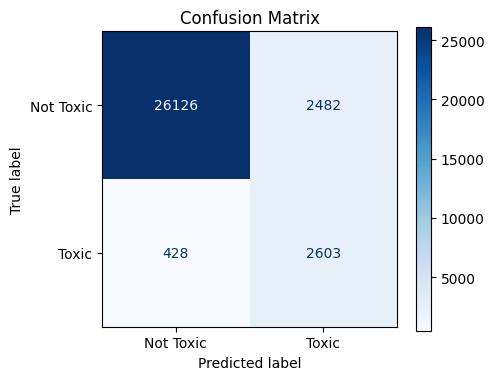

In [15]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Not Toxic', 'Toxic'],
    cmap='Blues', ax=ax
)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [16]:
# 5-Fold Cross Validation (F1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)

print(f'CV F1 scores : {cv_scores.round(4)}')
print(f'Mean F1      : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

CV F1 scores : [0.5987 0.6842 0.6974 0.687  0.755 ]
Mean F1      : 0.6845 ± 0.0500


In [17]:
from sklearn.metrics import f1_score, precision_score, recall_score

# ลอง threshold หลายค่า หาค่าที่ F1 ดีที่สุด
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7]

print(f"{'Threshold':>10} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print("-" * 42)
for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    p = precision_score(y_test, y_pred_t)
    r = recall_score(y_test, y_pred_t)
    f = f1_score(y_test, y_pred_t)
    print(f"{t:>10.2f} {p:>10.4f} {r:>8.4f} {f:>8.4f}")

 Threshold  Precision   Recall       F1
------------------------------------------
      0.30     0.4174   0.8997   0.5703
      0.35     0.4415   0.8888   0.5899
      0.40     0.4664   0.8789   0.6094
      0.45     0.4901   0.8697   0.6269
      0.50     0.5119   0.8588   0.6414
      0.55     0.5342   0.8456   0.6547
      0.60     0.5539   0.8304   0.6646
      0.65     0.5769   0.8209   0.6776
      0.70     0.5986   0.8093   0.6882


In [18]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'alpha': [0.0001, 0.001, 0.01],
    'loss': ['modified_huber'],
    'class_weight': ['balanced', {0: 1, 1: 3}, {0: 1, 1: 5}],
}

grid = GridSearchCV(
    SGDClassifier(max_iter=100, random_state=42),
    param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print(f'Best params : {grid.best_params_}')
print(f'Best CV F1  : {grid.best_score_:.4f}')

Fitting 3 folds for each of 9 candidates, totalling 27 fits
Best params : {'alpha': 0.001, 'class_weight': {0: 1, 1: 3}, 'loss': 'modified_huber'}
Best CV F1  : 0.7664


In [19]:
from sklearn.linear_model import LogisticRegression

best_model = LogisticRegression(
    C=1.0,                    #regularization
    class_weight={0:1, 1:3},  #ใช้ค่าเดิมที่ GridSearch บอกว่าดี
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

best_model.fit(X_train, y_train)

# Evaluate
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

print('=== Logistic Regression Report ===')
print(classification_report(y_test, y_pred_best, target_names=['Not Toxic', 'Toxic']))
print(f'ROC-AUC : {roc_auc_score(y_test, y_prob_best):.4f}')
print(f'F1 (Toxic): {f1_score(y_test, y_pred_best):.4f}')

=== Logistic Regression Report ===
              precision    recall  f1-score   support

   Not Toxic       0.98      0.98      0.98     28608
       Toxic       0.79      0.79      0.79      3031

    accuracy                           0.96     31639
   macro avg       0.88      0.88      0.88     31639
weighted avg       0.96      0.96      0.96     31639

ROC-AUC : 0.9745
F1 (Toxic): 0.7891


## 8. Save Model & Artifacts

In [20]:
with open('SGDC_Optuna_word_vectorizer.pkl', 'wb') as f:
    pickle.dump(word_vec, f)

with open('SGDC_Optuna_char_vectorizer.pkl', 'wb') as f:
    pickle.dump(char_vec, f)

with open('SGDC_Optuna_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('SGDC_Optuna_toxic_sgd_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print('All artifacts saved ✓')

All artifacts saved ✓


## 9. Inference Helper

In [21]:
def predict_toxicity(comment: str) -> dict:
    """Predict whether a comment is toxic."""
    raw   = comment
    clean = clean_text(comment)

    # Engineering features (single row)
    profanity = count_pattern(clean, PROFANITY_PATTERN)
    eng = pd.DataFrame([{
        'Character Count':                    len(raw),
        'Word Count':                         len(clean.split()),
        'Exclamation Count':                  raw.count('!'),
        'Profanity Count':                    profanity,
        'Strong Toxic Signal Flag':           int(profanity > 0),
        'Second-person Pronoun Count':        count_pattern(clean, SECOND_PERSON_PATTERN),
        'Repeated Character Pattern Count':   repeated_characters_score(raw),
        'Average Word Length':                sum(len(w) for w in clean.split()) / max(len(clean.split()), 1),
        'Uppercase Ratio':                    uppercase_ratio(raw),
        'Question Mark Count':                raw.count('?'),
        'Repeated Punctuation Count':         repeated_punctuation_count(raw),
        'Identity-group Term Count':          count_pattern(clean, IDENTITY_PATTERN),
        'URL Count':                          len(re.findall(r'http\S+|www\S+', raw)),
        'Negation Count':                     count_pattern(clean, NEGATION_PATTERN),
        'Non-toxic Negation Pattern Count':   count_pattern(clean, NON_TOXIC_NEGATION_PATTERN),
        'Short/Unclear Without Toxic Signal Flag': short_unclear_without_toxic_signal(clean, profanity),
    }])

    X_w  = word_vec.transform([clean])
    X_c  = char_vec.transform([raw])
    X_e  = csr_matrix(scaler.transform(eng.values))
    X    = hstack([X_w, X_c, X_e])

    label = model.predict(X)[0]
    prob  = model.predict_proba(X)[0][1]

    return {'label': 'Toxic' if label == 1 else 'Not Toxic', 'probability': round(prob, 4)}


# Quick test
samples = [
    "You are such an idiot, go fuck yourself!",
    "Thanks for fucing the explanation, that really helped!",
    "I do not think this policy is fair to everyone.",
]

for s in samples:
    result = predict_toxicity(s)
    print(f"{result['label']:10s} ({result['probability']:.2%})  →  {s[:60]}")

Toxic      (100.00%)  →  You are such an idiot, go fuck yourself!
Not Toxic  (11.97%)  →  Thanks for fucing the explanation, that really helped!
Not Toxic  (0.00%)  →  I do not think this policy is fair to everyone.
